FEUILLE DE TP 3

---
# Polynôme interpolateur de Lagrange (Partie 1)
---

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np                       # pour les numpy array
from scipy.interpolate import lagrange   # interpolation de Lagrange
import matplotlib.pyplot as plt          # librairie graphique

---

# I- Préliminaires : 
## Suites - Convergence- Ordre (Vitesse) - Constante asymptotique

---

Dans la suite du cours nous produirons des méthodes numériques d'approximation. C'est-à-dire permettant 
de construire des solutions approchées aux problèmes sous la main. Ceci genèrera des suites numériques. 

Et la qualité de l'approximation sera mésurée par la manière donc la suite des solutions approchées converge vers la solution exacte.

Nous réservons donc cette partie de la fiche à l'analyse de convergences des suites.

**Rappels (voir cours):**

Soit $(x_n)_{n\in\mathbb{N}}$ une suite d'éléments de $\mathbb{R}^n$ et $x^*$ un élement de $\mathbb{R}^n$.  
On désigne par $\| . \|$ une norme sur $\mathbb{R}^n$ (on rappelle que $\mathbb{R}^n$ étant de dimension fine, 
touttes les normes y sont équivalentes).
>- **Définitions:**
>>- La suite est dite **convergente d'ordre** $q\in \mathbb{N}$ si et seulement si : $\exists K_q \in\mathbb{R}^*_+$ tel que  $\displaystyle \lim_{n -> \infty} \frac{\|x_{n+1} - x^*\|}{\|x_n - x^*\|^q} = K_q$. 
>>- La constante $K_r$ est appelée **constante asymptotique** de la suite. Elle est dificile à obtenir en pratique (puisqu'il faut pour cela disposer de la limite $x^*$). Ainsi dans la pratique on arrive plutôt à obtenir un majorant de $K_r$.
>>- La quantité $e_n = x^* - x_n$ est appelée **l'erreur à l'itération $n$**.
>- **Caractérisation:** 
ainsi une suite sera dite **convergente d'ordre $q$ ssi**:
$$
\exists N\in\mathbb{N}, \exists A, B \in\mathbb{R} : \forall n > N, 0 < A < \frac{\|e_{n+1}\|}{\|e_n\|^q} < B < \infty.
$$

Le but de l'analyse de la suite est de :
>- dire si la suite converge
>- et si elle converge,
>>- déterminer l'ordre de convergence **q**
>>- déterminer (**si possible**) la constante  **Kq** (qui joue un rôle important lorsque la convergence est d'ordre 1).


## Exercice 1 :  Ordre de convergence des suites


### Question 1.1:

> Fournir une fonction `TraquerOrdre(xn, limit)`
qui calcul l'ordre de convergence de la suite `xn`


In [2]:
## METTRE LE CODE ICI
def TraquerOrdre(xn, lim = 0.0, ax = None, title=''):
    '''
    Fonction qui calcule l'ordre de convergence de la suite
    passée en argument
    ENTREE:
      xn    -> tableau des éléments de la suite
      lim   -> limite de la suite
      ax    -> est la fenêtre graphique sur laquelle le dessin s'effectue 
      title -> le titre à associer
    SORTIE:
       - ordre de la suite
       - graphique qui trace à l'echelle log 
           - la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|)
           - la courbe de regression linéaire associée
    '''
    #COMPLETER
    # Tracer la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|) en pointillés   
    ...
    # Estimer l' ordre q de convergence de la suite (utiliser une des approches vues en cours)
    ...
    # Représenter sur le même graphique la courbe de pente q (ici q est dans IR) en ligne continue
    ... 
    # Mettre les légendes 
    ...
    # Mettre le titre il doit contenir l'information sur l'ordre de convergence estimée 
    ...

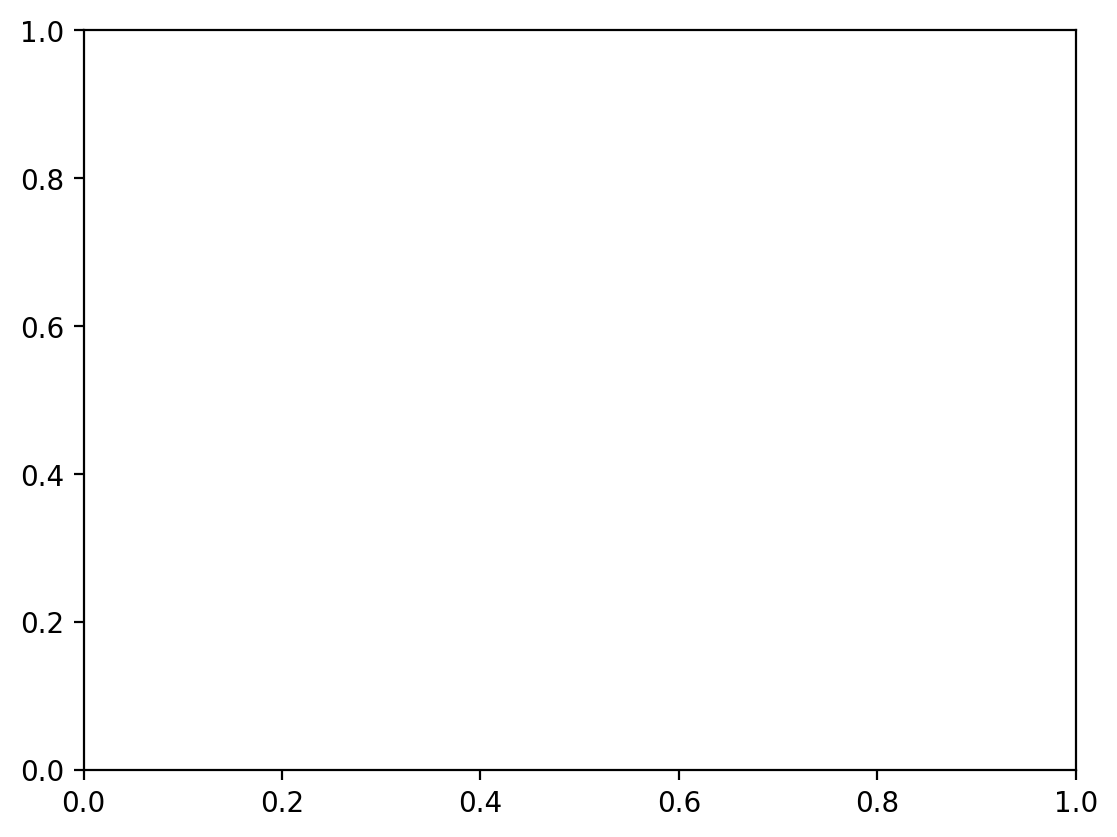

In [3]:
# Tester rapidement votre algorithme
n = np.arange(1,30)
a = (0.1)**n
fig, ax = plt.subplots(1,1)
TraquerOrdre(a, 0.0, ax, title="$ n \mapsto (0.1)^n $")


### Question 1.2
 On considère les suites suivantes ;
  $$ u_n = (0.08)^n, \qquad v_n = (0.99)^n  \qquad  w_n  = (0.8)^{2^n}$$
> Calculer et affichera les 30 premiers termes de ces suites. 
> Déduire graphiquement qu'elles convergent. *On pourra représenter la ligne horizontale de hauteur `0` (l'axe des abcisses)* 


In [4]:
# METTRE VOTRE CODE ICI 





### Question 1.3

 Déterminer si elles convergent, **l'ordre** de convergence des suites ci-dessus

>- Vous pourrez vous servir de votre fonction `TraquerOrdre`  si elle est fonctionnelle
>- Vous pourrez aussi représenter sur un même graphique la courbe $\log(e_n) \mapsto \log(e_{n+1})$, ainsi que des droites de pente 1, 2, 3 passant par un point bien choisi.
 

In [5]:
# METTRE VOTRE CODE ICI





---
## Exercice 2 :  Termes ajoutés par itération 

### Question 2.1

 Pour chacune des suites $(u_n)$ et $(v_n)$ ci-dessus

* calculer à la main sa constante **asymptotique**  `K`
* et afficher la valeur de $ \frac{-1}{\log_{10}(K)}$


In [6]:
## METTRE LE CODE ICI

Ku = ...
Kv = ...

# COMPLETEZ


### Question 2.2
 
 Montrer et vérifier numériquement qu'à chaque itération  
 * avec la suite $v_n$ il faut **230** itérations pour gagner une décimale
 * avec la suite $u_n$ on gagne **une** décimale à chaque itération
 
*Formatter une sortie du type* 
```
 ---------------------------------
|  n  |           un            |
---------------------------------
|  0  |  1.000000000000000e+00  |
|  1  |  8.000000000000000e-02  |
|  2  |  6.400000000000000e-03  |
|  3  |  5.120000000000001e-04  |
|  4  |  4.096000000000000e-05  |
|  5  |  3.276800000000001e-06  |
|  6  |  2.621440000000000e-07  |
|  7  |  2.097152000000000e-08  |
|  8  |  1.677721600000000e-09  |
|  9  |  1.342177280000000e-10  |
---------------------------------
On voit bien qu'on gagne un chiffre décimal à chaque itération 
```

In [7]:
# METTRE VOTRE CODE ICI  pour un





In [8]:
#METTRE VOTRE CODE ICI  pour vn





### Question 2.3 : Interprétations 

>- Commentez les résultats des questions précédentes en remaquant que :
>>- les deux suites sont bien convergentes d'ordre 1,
>>- mais que l'une des suites converge plus vite que l'autre.

>- Si ces suites représentaient chacune la suite des erreurs de deux méthodes différentes d'approximation d'un même problème continu. Laquelle des méthodes serait la plus conseillée ?




In [9]:
# REPONSE ICI




---

# II-  Polynôme interpolateur de Lagrange
---

Nous rappelons le résultat d'existence et d'unicité vu en cours

> **(Polynôme interpolateur de Lagrange)**<br>
> Etant donnés $N$ un entier strictement positif, $x_1,\ldots,x_N$ des réels deux à deux distincts et $y_1,\ldots,y_N$ des réels, il existe un unique polynôme $P$ qui vérifie
> $$ P\in\mathbb{R}_{N-1}[X], \qquad P(x_i)=y_i, \quad 1\leq i\leq N.$$

---
## Exercice 3 :  Construction en utilisant les modules `numpy` et `scipy`

Le module `numpy` permet la manipulation de polynômes réels à l'aide de la classe `poly1d`. Voici un exemple pour le polynôme $P=X^2-2$

```python
P = np.poly1d([1, 0, -2])
print(P)
```

Il est possible de faire des manipulations algébriques sur les polynômes :

```python
X = np.poly1d([1, 0])
P = X**2 - 2
print(P)
```

Il est également possible d'évaluer un polynôme comme une fonction (évaluation sur un scalaire ou sur un tableau `numpy`) :

```python
print(P(1))
print(P(np.linspace(0, 1, 11)))
```

In [10]:
# COPIER ET TESTER LES CODES CI-DESSUS




In [11]:
# COPIER ET TESTER LES CODES CI-DESSUS




In [12]:
# COPIER ET TESTER LES CODES CI-DESSUS



Le module `scipy.interpolate` permet de déterminer le polynôme interpolateur à l'aide de la fonction `lagrange`. Voici un exemple d'utilisation pour déterminer le polynôme interpolateur de Lagrange aux points $(0, -2)$, $(1,-1)$ et $(2, 2)$ (c'est encore et toujours le polynôme $X^2-2$...)

```python
from scipy.interpolate import lagrange
x = np.array([0, 1, 2])
y = np.array([-2, -1, 2])
P = lagrange(x, y)
print(P)
```

In [15]:
# COPIER ET TESTER LES CODES CI-DESSUS




   2
2 x - 4


### Question 3.1

> Proposez une fonction `interp` qui 
> * prend en argument deux `ndarray` `x` et `y` de taille `N` et un `ndarray` `xx` de taille `M` ;
> * calcule le polynôme interpolateur de Lagrange aux points donnés par les vecteurs `x` et `y` en utilisant les fonctions des modules `numpy` et `scipy` ;
> * retourne l'évaluation de ce polynôme aux points du vecteur `xx`.

*Veillez à commenter votre fonction.*

In [17]:
def interp(x, y, xx):
    """
    calcule et évalue le polynôme interpolateur de Lagrange
    en utilisant :
        . la fonction lagrange du module scipy.interpolate
        . la classe poly1d du module numpy
    
    Parameters
    ----------
    
    x: ndarray
        abscisses des points d'interpolation
        
    y: ndarray
        ordonnées des points d'interpolation
        
    xx: ndarray
        abscisses des points d'évaluation
        
    Returns
    -------
    
    ndarray
        ordonnées des points d'évaluation
    """
    # COMPLETEZ

### Question 3.2

> Afin de tester votre fonction : en prenant $N=5$,
> 1. prenez $N$ points équirépartis entre 0 et 1 (ce sera notre vecteur `x`) ;
> 2. générez $N$ valeurs aléatoires entre 0 et 1 (ce sera notre vecteur `y`) ;
> 3. tracez dans une fenêtre graphique le nuage de points d'abscisses `x` et d'ordonnées `y` à l'aide d'une commande `scatter` ;
> 4. ajoutez le tracé du polynôme interpolateur en prenant `xx` un vecteur de taille grande (plutôt 100 ou 200 points équi-répartis entre 0 et 1) ;
> 5. vérifiez que le polynôme interpolateur passe bien par les points d'interpolation.

In [18]:
#METTRE LE CODE ICI

N = 5


# COMPLETEZ 


---
## Exercice 4 : Test de l'interpolation sur quelques fonctions

Nous allons à présent tester l'interpolation en prenant comme points d'interpolation des points qui sont sur le graphe de ces 4 fonctions. 

\begin{align}
f_0(x) &= \exp(-3(x-1.2)^2), &
f_1(x) &= \frac{x^2-2}{1+2x},\\
f_2(x) &= \frac{1}{1+(x-1.5)^2},&
f_3(x) &= \frac{\sin(2\pi x)}{1.1 - \sin(\pi x)}.
\end{align}



### Question 4.1

> Définissez ces 4 fonctions et tracez les sur l'intervalle $[0, 3]$.

In [19]:
# METTRE LE CODE ICI
# Définition des fonctions



In [20]:
# METTRE LE CODE ICI
# Graphique des fonctions

a, b = 0, 3

#COMPLETEZ


### Question 4.2

> * Ajoutez sur les figures précédentes les polynômes interpolateurs qui passent par $N$ points équi-répartis des graphes des fonctionss avec $N\in\lbrace 4, 8, 12, 16, 20\rbrace$.
> * Que remarquez-vous lorsque $N$ augmente ?

In [21]:
# METTRE LE CODE ICI

a, b = 0, 3

# COMPLETTEZ
